# Exercise 2: Boosting

## Do not start the exercise until you fully understand the submission guidelines.


* The homework assignments are executed automatically. 
* Failure to comply with the following instructions will result in a significant penalty. 
* Appeals regarding your failure to read these instructions will be denied. 
* Kind reminder: the homework assignments contribute 60% of the final grade.


## Read the following instructions carefully:

1. This Jupyter notebook contains all the step-by-step instructions needed for this exercise.
1. Write **efficient**, **vectorized** code whenever possible. Some calculations in this exercise may take several minutes when implemented efficiently, and might take much longer otherwise. Unnecessary loops will result in point deductions.
1. You are responsible for the correctness of your code and should add as many tests as you see fit to this jupyter notebook. Tests will not be graded nor checked.
1. You are allowed to use functions and methods from the [Python Standard Library](https://docs.python.org/3/library/).
1. Your code must run without errors. Use at least `numpy` 1.15.4. Any code that cannot run will not be graded.
1. Write your own code. Cheating will not be tolerated.
1. Submission includes a zip file that contains this notebook, with your group number and ID as the file name. For example, `hw2_13_123456789_987654321.zip` if you submitted in pairs and `hw2_13_123456789.zip` if you submitted the exercise alone. The name of the notebook should follow the same structure.
   
Please use only a **zip** file in your submission.

---
---

## Please sign that you have read and understood the instructions: 

### *** YOUR RUNI EMAILS HERE ***

guy.benari@post.runi.ac.il
---


In [57]:
# Import necessary libraries
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

np.random.seed(42)

# Design your algorithm
Make sure to describe the algorithm, its limitations, and describe use-cases.

AdaBoost uses exponential loss $L(H) = \sum_{i=1}^{n}{ \exp(-y_i \cdot H(x_i))}$ where $y_i \in \{-1, +1\}$  (binary classifer).

We build the ensemble classifer by $H_{t+1} = H_t + \alpha h$, where $h$ is a weak learner of a  decision tree of depth 1 with $\alpha$ impact.
So $L(H_{t+1}) = \sum_{i=1}^{n} \exp(-y_i (H_t(x_i) + \alpha h(x_i))) = \sum_{i=1}^{n} \exp(-y_i H_t(x_i)) \cdot \exp(-y_i \alpha h(x_i))$
Let $w_i = \exp(-y_i H_t(x_i))$ So $$L(H_{t+1}) = \sum_{i=1}^{n} w_i \exp(-y_i \alpha h(x_i))$$

So the error term is $$\epsilon_t = \frac{\sum_{i=1}^{n} w_i \mathbb{I}(y_i \neq h(x_i))}{\sum_{i=1}^{n} w_i}$$
So after rearranging terms: $$\alpha_t = \frac{1}{2} \ln(\frac{1 - \epsilon_t}{\epsilon_t})$$

So have update rule:$$w_{i}^{(t+1)} = w_i^{(t)} \cdot \exp(-\alpha_t \cdot y_i \cdot h(x_i))$$

Normalizing all $w_i $

We will keep updating the model with new weak learners until the number of weak learners passes some threshold or unable to get weak learner with error < 0.5. Each weak learner will be picked by the split that reduces the error rate of the entire ensemble learning .

Algorithm:
Intially set all $w_i = 1/m$ for all data points.
Determine next best weak learner by looping through all feature splits
Calculate its $\alpha$ and update $H_{t+1}$
Keep updating until reach number of weak learners or unable to find good enough weak learner. 

predict by $H(x)$ sign.


Therefore hyperparameters are 
- Number of weak learners (stumps)
- ? learning rate shrinkage factor?

Limitations:
- Training can't be parallelized as is sequential in construction
-  Sensitivity to outliers due to exponential loss which leads to larger weight


Use cases:
- Binary classifcation
- ...



# Your implementations
You may add new cells, write helper functions or test code as you see fit.
Please use the cell below and include a description of your implementation.
Explain code design consideration, algorithmic choices and any other details you think is relevant to understanding your implementation.
Failing to explain your code will lead to point deductions.

In [58]:
import numpy as np

class AdaBoostCustom:
    def __init__(self, T):
        self.T = T
        self.alphas = []
        self.models = []

    def _best_stump(self, X, y, w):
        n_samples, n_features = X.shape
        best_err = float('inf')
        best_feat, best_thresh, best_pol, best_is_cat = None, None, None, None

        for feat in range(n_features):
            col = X[:, feat]
            try:
                col.astype(float)
                is_categorical = False
            except (ValueError, TypeError):
                is_categorical = True

            potential_threshold = np.unique(col)

            for cand in potential_threshold:
                if is_categorical:
                    preds = np.where(col == cand, +1, -1)
                else:
                    preds = np.where(col.astype(float) <= float(cand), +1, -1)
                err = np.sum(w[preds != y]) / np.sum(w)

                if err > 0.5:
                    err = 1 - err
                    polarity = -1
                else:
                    polarity = +1

                if err < best_err:
                    best_err   = err
                    best_feat  = feat
                    best_thresh = cand
                    best_pol   = polarity
                    best_is_cat = is_categorical

        return best_feat, best_thresh, best_pol, best_is_cat, best_err

    def _stump_predict(self, X, model):
        feat, thresh, polarity, is_categorical = model
        col = X[:, feat]
        if is_categorical:
            return np.where(col == thresh, polarity, -polarity)
        else:
            return np.where(col.astype(float) <= float(thresh), polarity, -polarity)

    def fit(self, X, y, categorical_features=None):
        X = np.array(X, dtype=object)
        y = np.array(y, dtype=float)
        n, d = X.shape

        w = np.full(n, 1.0 / n)

        for t in range(self.T):
            feat, thresh, polarity, is_cat, eps = self._best_stump(X, y, w)

            if eps >= 0.5:
                break

            eps   = max(eps, 1e-10)
            alpha = 0.5 * np.log((1.0 - eps) / eps)

            model = (feat, thresh, polarity, is_cat)
            self.models.append(model)
            self.alphas.append(alpha)

            preds = self._stump_predict(X, model)
            w = w * np.exp(-alpha * y * preds)
            w /= w.sum()

    def predict(self, X):
        X = np.array(X, dtype=object)
        H = sum(
            alpha * self._stump_predict(X, model)
            for alpha, model in zip(self.alphas, self.models)
        )
        return np.sign(H)

# Generate data
Please use the cell below to discuss your dataset choice and why it is appropriate (or not) for this algorithm.

The make_moons dataset from sklearn will indicate the effectiveness and correct implentation of the AdaBoost algorithm. This is because the data is inherently non-linear so regular learners and weak learners will struggle but with AdaBoost creating stumps each stump will achieve error rate below 50% but with all of them combined a much higher accuracy should be achievable.

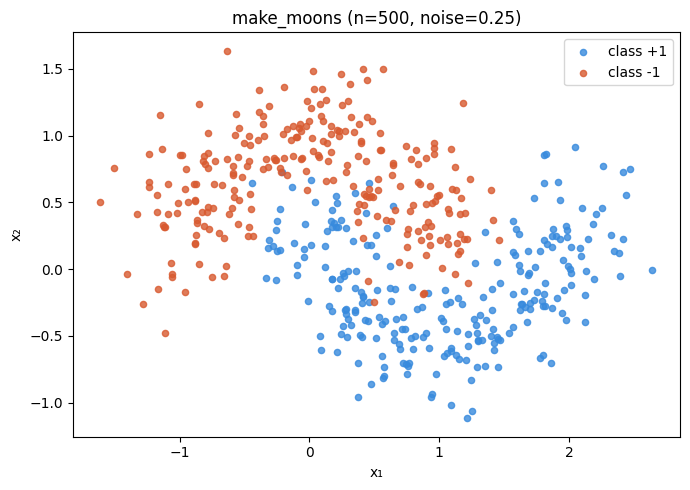

In [59]:
# Your code here
#XOR dataset 
np.random.seed(42)
from sklearn.datasets import make_moons
X, y = make_moons(n_samples=500, noise=0.25, random_state=42)
y = np.where(y == 0, -1, +1)


plt.figure(figsize=(7, 5))
plt.scatter(X[y == 1, 0], X[y == 1, 1], c='#378ADD', s=20, label='class +1', alpha=0.8)
plt.scatter(X[y == -1, 0], X[y == -1, 1], c='#D85A30', s=20, label='class -1', alpha=0.8)
plt.legend()
plt.xlabel('x₁')
plt.ylabel('x₂')
plt.title('make_moons (n=500, noise=0.25)')
plt.tight_layout()
plt.show()


# AdaBoost demonstration 
Demonstrate your AdaBoost implementation.

Add plots and figures. 

Please use the cell below to describe your results and tests.

Describe the difference between your implementation and the sklearn implementation. Hint: you can look at the documentation.

Custom  accuracy: 0.88
Sklearn accuracy: 0.87


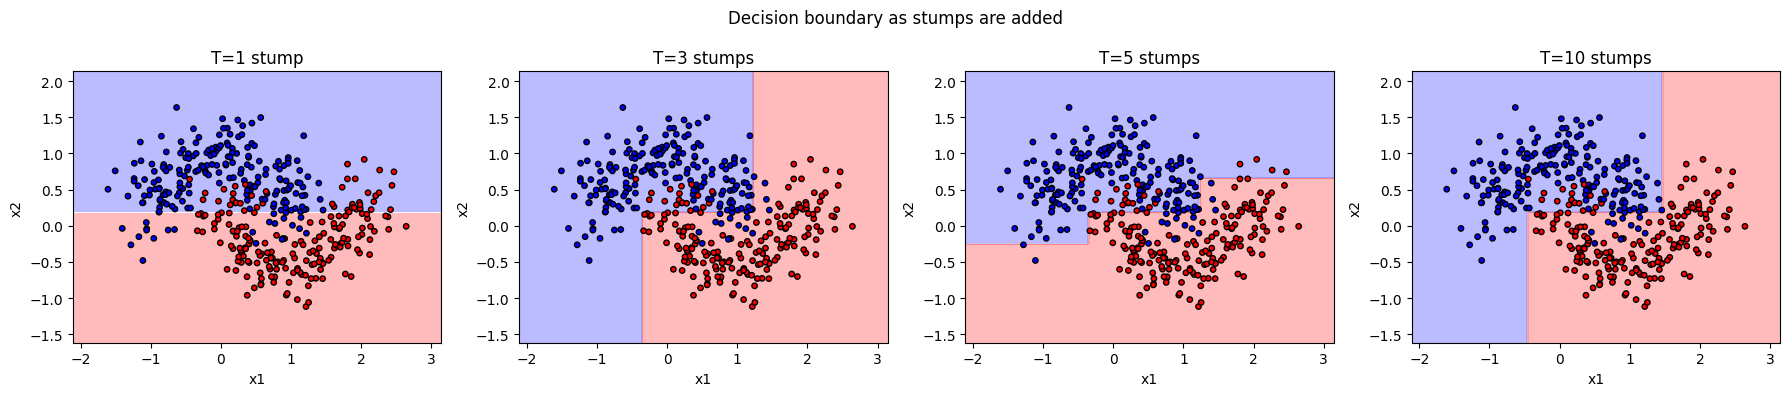

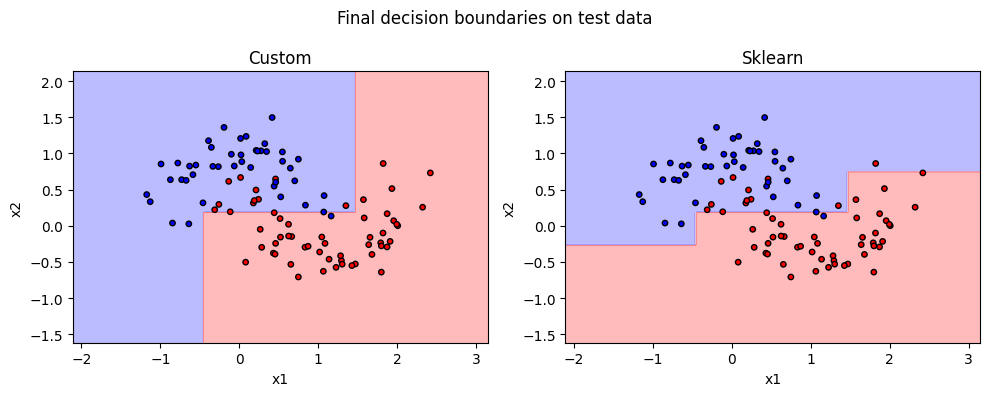

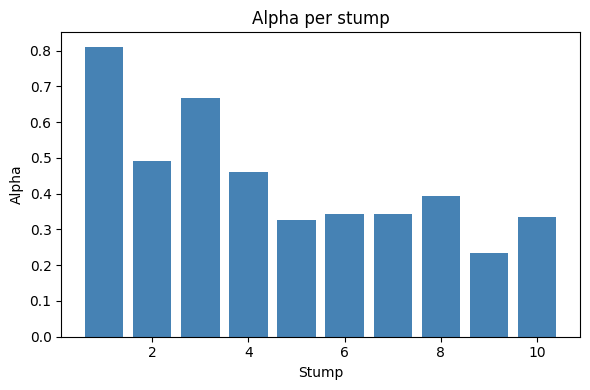

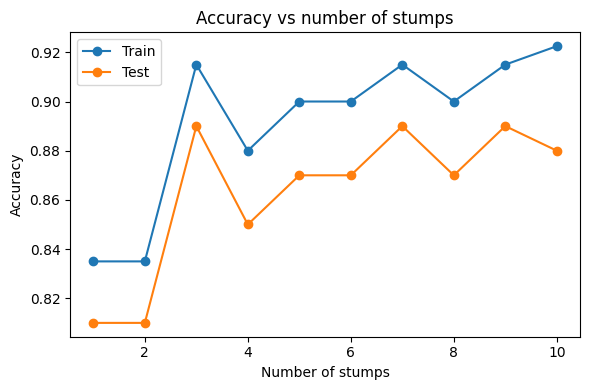

In [60]:
custom_model = AdaBoostCustom(T=10)
sklearn_model = AdaBoostClassifier(n_estimators=10, random_state=42)

# Your code here

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

custom_model.fit(X_train, y_train)
sklearn_model.fit(X_train, np.where(y_train == -1, 0, 1))  


custom_preds  = custom_model.predict(X_test)
sklearn_preds = np.where(sklearn_model.predict(X_test) == 0, -1, 1)

print(f"Custom  accuracy: {accuracy_score(y_test, custom_preds)}")
print(f"Sklearn accuracy: {accuracy_score(y_test, sklearn_preds)}")

# Create meshgrid for decision boundary plots
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))
grid = np.c_[xx.ravel(), yy.ravel()]

# Stumps over time 
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle("Decision boundary as stumps are added")
for ax, t in zip(axes, [1, 3, 5, 10]):
    H = sum(
        alpha * custom_model._stump_predict(grid, m)
        for alpha, m in zip(custom_model.alphas[:t], custom_model.models[:t])
    )
    ax.contourf(xx, yy, np.sign(H).reshape(xx.shape), alpha=0.3, cmap='bwr')
    ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='bwr', edgecolors='k', s=15)
    ax.set_title(f"T={t} stump{'s' if t > 1 else ''}")
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")

plt.tight_layout()
plt.show()

#sklearn vs custom final boundary
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle("Final decision boundaries on test data")

custom_zz  = custom_model.predict(grid).reshape(xx.shape)
sklearn_zz = np.where(sklearn_model.predict(grid) == 0, -1, 1).reshape(xx.shape)

for ax, zz, title in zip(axes, [custom_zz, sklearn_zz], ["Custom", "Sklearn"]):
    ax.contourf(xx, yy, zz, alpha=0.3, cmap='bwr')
    ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='bwr', edgecolors='k', s=15)
    ax.set_title(title)
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")

plt.tight_layout()
plt.show()

#alpha per stump 
plt.figure(figsize=(6, 4))
plt.bar(range(1, len(custom_model.alphas) + 1), custom_model.alphas, color='steelblue')
plt.title("Alpha per stump")
plt.xlabel("Stump")
plt.ylabel("Alpha")
plt.tight_layout()
plt.show()

# T over time accuracy 
train_accs, test_accs = [], []
for t in range(1, len(custom_model.alphas) + 1):
    H_train = sum(a * custom_model._stump_predict(X_train, m)
                  for a, m in zip(custom_model.alphas[:t], custom_model.models[:t]))
    H_test  = sum(a * custom_model._stump_predict(X_test, m)
                  for a, m in zip(custom_model.alphas[:t], custom_model.models[:t]))
    train_accs.append(accuracy_score(y_train, np.sign(H_train)))
    test_accs.append(accuracy_score(y_test,  np.sign(H_test)))

plt.figure(figsize=(6, 4))
plt.plot(range(1, len(train_accs) + 1), train_accs, label='Train', marker='o')
plt.plot(range(1, len(test_accs)  + 1), test_accs,  label='Test',  marker='o')
plt.title("Accuracy vs number of stumps")
plt.xlabel("Number of stumps")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

## Results and Comparison with sklearn

Our custom AdaBoost achieves **88% accuracy** on the test set, while sklearn's `AdaBoostClassifier` achieves **87%**. The near-identical performance validates the correctness of our implementation.

### Key differences between our implementation and sklearn's AdaBoostClassifier:

- **Boosting variant**: Our implementation uses classic discrete AdaBoost (SAMME), which relies on hard class predictions from each weak learner. Sklearn defaults to SAMME.R, a real-valued variant that uses the full class probability estimates from weak learners, generally converging faster.
- **Weak learner**: We use a custom decision stump that exhaustively searches all unique feature thresholds to minimize weighted error. Sklearn uses `DecisionTreeClassifier(max_depth=1)` which optimizes Gini impurity and natively supports sample weights.
- **Multi-class support**: Our implementation is binary only ($y \in \{-1, +1\}$). Sklearn supports multi-class classification via both SAMME and SAMME.R.
- **Learning rate**: We do not implement a learning rate (equivalent to `learning_rate=1`). Sklearn provides a configurable `learning_rate` parameter that shrinks $\alpha_t$ each round, trading off the number of estimators against each one's individual contribution.
- **Early stopping**: We stop boosting if $\epsilon_t \geq 0.5$ (no useful weak learner found). Sklearn stops if $\epsilon_t \geq 1 - 1/n\_classes$ or if a perfect fit is achieved.

The slight accuracy difference is expected because SAMME.R uses the full probability output of the weak learner rather than just its hard prediction, which generally leads to faster convergence but can behave differently on small ensembles (T=10).

### Plots:
- **Decision boundary evolution** — how the boundary becomes more complex as stumps are added
- **Custom vs sklearn boundaries** — visual confirmation that both produce similar decision regions
- **Alpha per stump** — the weight assigned to each weak learner (higher = more informative stump)
- **Accuracy vs T** — how train/test accuracy improves with more stumps

# Generate additional data sets
Generate at least two experimental datasets with binary labels, designed to demonstrate specific properties of AdaBoost (e.g., handling noise or overfitting).

Add plots and figures.

Please use the cell below to describe your suggested approach in detail. Use formal notations where appropriate.

Describe and discuss your results.

## Experimental Datasets

We design two datasets, each targeting a specific known property of AdaBoost:

### Dataset 1: XOR Pattern (non-linear boundary via axis-aligned stumps)
The XOR pattern assigns labels based on $y = \text{sign}(x_1 \cdot x_2)$. Points in the top-right and bottom-left quadrants get label $+1$; points in the top-left and bottom-right get $-1$. This creates a non-linear boundary that **no single decision stump can solve** — a stump can only make one axis-aligned cut, but XOR requires cuts on both axes. This demonstrates how boosting combines multiple weak learners to approximate complex decision boundaries.

### Dataset 2: Noisy Labels (sensitivity to outliers)
We generate two well-separated Gaussian blobs using `make_blobs` (2 centers, `cluster_std=1.0`), then **randomly flip 20% of the labels**. Without noise, this is trivially separable. With flipped labels, the mislabeled points act as outliers deep inside the wrong class. Since AdaBoost uses exponential loss, it aggressively upweights these misclassified outliers — as $T$ increases, AdaBoost overfits to the noisy points, causing test accuracy to plateau or degrade. This directly demonstrates the theoretical limitation described in Part 1 (sensitivity to outliers due to exponential loss).

Both datasets use 2000 samples and 2 features for easy visualization.

In [61]:
# ============================================================
# Dataset 1: XOR Pattern
# ============================================================
np.random.seed(42)
X_xor = np.random.randn(2000, 2)
y_xor = np.where(X_xor[:, 0] * X_xor[:, 1] > 0, +1, -1)

X_xor_train, X_xor_test, y_xor_train, y_xor_test = train_test_split(
    X_xor, y_xor, test_size=0.2, random_state=42
)

# ============================================================
# Dataset 2: Noisy Labels (20% label flipping)
# ============================================================
from sklearn.datasets import make_blobs

X_noisy, y_noisy = make_blobs(
    n_samples=2000, n_features=2, centers=2,
    cluster_std=1.0, random_state=42
)
# Convert to {-1, +1}
y_noisy = np.where(y_noisy == 0, -1, +1)

# Flip 20% of labels to simulate noise
rng = np.random.default_rng(42)
noise_rate = 0.20
n_flip = int(len(y_noisy) * noise_rate)
flip_idx = rng.choice(len(y_noisy), size=n_flip, replace=False)
y_noisy[flip_idx] *= -1

X_noisy_train, X_noisy_test, y_noisy_train, y_noisy_test = train_test_split(
    X_noisy, y_noisy, test_size=0.2, random_state=42
)

print(f"XOR dataset: {X_xor.shape[0]} samples, train={X_xor_train.shape[0]}, test={X_xor_test.shape[0]}")
print(f"Noisy dataset: {X_noisy.shape[0]} samples, train={X_noisy_train.shape[0]}, test={X_noisy_test.shape[0]}")
print(f"Noisy dataset: {n_flip} labels flipped ({noise_rate*100:.0f}% noise)")

XOR dataset: 2000 samples, train=1600, test=400
Noisy dataset: 2000 samples, train=1600, test=400
Noisy dataset: 400 labels flipped (20% noise)


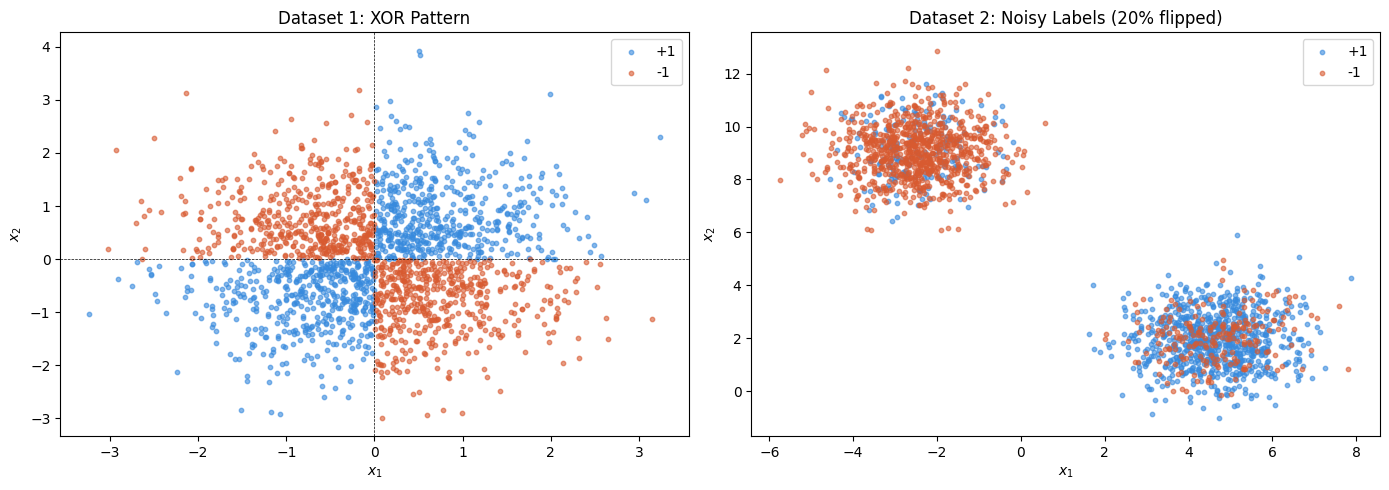

In [62]:
# ============================================================
# Visualize both datasets
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# XOR
ax = axes[0]
ax.scatter(X_xor[y_xor == 1, 0], X_xor[y_xor == 1, 1], c='#378ADD', s=10, alpha=0.6, label='+1')
ax.scatter(X_xor[y_xor == -1, 0], X_xor[y_xor == -1, 1], c='#D85A30', s=10, alpha=0.6, label='-1')
ax.axhline(0, color='k', linewidth=0.5, linestyle='--')
ax.axvline(0, color='k', linewidth=0.5, linestyle='--')
ax.set_title('Dataset 1: XOR Pattern')
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.legend()

# Noisy
ax = axes[1]
ax.scatter(X_noisy[y_noisy == 1, 0], X_noisy[y_noisy == 1, 1], c='#378ADD', s=10, alpha=0.6, label='+1')
ax.scatter(X_noisy[y_noisy == -1, 0], X_noisy[y_noisy == -1, 1], c='#D85A30', s=10, alpha=0.6, label='-1')
ax.set_title('Dataset 2: Noisy Labels (20% flipped)')
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.legend()

plt.tight_layout()
plt.show()

# Test algorithms
Test your AdaBoost, a library implementation of AdaBoost and at least two additional models, one of which must be another boosting algorithm on your two datasets.

Add plots and figures.

Please use the cell below to describe your suggested approach in detail. Use formal notations where appropriate.

Describe and discuss your results.

## Experimental Approach

### Models
We compare four classifiers on both experimental datasets:
1. **AdaBoost (Custom)** — our from-scratch implementation using depth-1 decision stumps as weak learners
2. **AdaBoost (sklearn)** — `AdaBoostClassifier` using the SAMME.R algorithm with depth-1 stumps
3. **GradientBoosting** — `GradientBoostingClassifier`, a sequential boosting method that minimizes log-loss via gradient descent. Unlike AdaBoost's exponential loss, log-loss is less sensitive to outliers.
4. **RandomForest** — `RandomForestClassifier`, a bagging method that trains independent trees on bootstrap samples and aggregates predictions by majority vote.

### Hyperparameters
We run two experiments varying one hyperparameter at a time:

**Experiment 1 — Vary $T$ (number of estimators):**
- $T \in \{5, 10, 25, 50, 100\}$
- Fixed `max_depth = 3` for GradientBoosting and RandomForest
- AdaBoost always uses depth-1 stumps (by design)

**Experiment 2 — Vary `max_depth`:**
- `max_depth` $\in \{1, 2, 3, 5, 7, 10\}$
- Fixed $T = 50$
- Note: AdaBoost (both versions) always uses depth-1 stumps, so its curve is flat — this is intentional and highlights a fundamental design constraint of the algorithm.

### Metric
We use **accuracy** as our performance metric:
$$\text{Accuracy} = \frac{\text{\# correct predictions}}{\text{\# total predictions}}$$

**Justification:** Both datasets are balanced (equal class sizes), so accuracy is a fair and unbiased measure. In imbalanced settings, metrics like F1-score or AUC would be preferred, but for balanced binary classification, accuracy directly reflects the fraction of correctly classified samples without any bias toward either class.

### Expected Outcomes
- **XOR dataset**: Models with deeper trees (GradientBoosting, RandomForest at `max_depth` $\geq 2$) should outperform AdaBoost's stumps, since the XOR boundary requires splits on both features. AdaBoost must approximate the diagonal boundary with many axis-aligned cuts.
- **Noisy Blobs dataset**: All models should hit an accuracy ceiling of approximately $1 - \text{noise\_rate} = 0.80$, since 20% of labels are incorrect. Deeper trees may overfit to the mislabeled points, causing accuracy to degrade at high `max_depth`.

In [63]:
# Set up models
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score

# Hyperparameters to test
T_values = [5, 10, 25, 50, 100]
depth_values = [1, 2, 3, 5, 7, 10]  # max_depth for tree-based models

def build_models(T, max_depth=1):
    """Return a dict of model_name -> model for given T and max_depth."""
    return {
        'AdaBoost (Custom)': AdaBoostCustom(T=T),
        'AdaBoost (sklearn)': AdaBoostClassifier(n_estimators=T, random_state=42),
        'GradientBoosting': GradientBoostingClassifier(n_estimators=T, max_depth=max_depth, random_state=42),
        'RandomForest': RandomForestClassifier(n_estimators=T, max_depth=max_depth, random_state=42),
    }

# Datasets to evaluate
datasets = {
    'XOR': (X_xor_train, X_xor_test, y_xor_train, y_xor_test),
    'Noisy Blobs': (X_noisy_train, X_noisy_test, y_noisy_train, y_noisy_test),
}

print('Models: AdaBoost (Custom), AdaBoost (sklearn), GradientBoosting, RandomForest')
print(f'T values: {T_values}')
print(f'max_depth values: {depth_values}')
print(f'Datasets: {list(datasets.keys())}')

Models: AdaBoost (Custom), AdaBoost (sklearn), GradientBoosting, RandomForest
T values: [5, 10, 25, 50, 100]
max_depth values: [1, 2, 3, 5, 7, 10]
Datasets: ['XOR', 'Noisy Blobs']


In [64]:
# ============================================================
# Experiment 1: Vary T (number of estimators), fixed max_depth=3
# ============================================================
results_T = {}  # results_T[dataset_name][model_name] = {'acc_train': [...], 'acc_test': [...]}

for ds_name, (X_tr, X_te, y_tr, y_te) in datasets.items():
    results_T[ds_name] = {}
    for T in T_values:
        models = build_models(T, max_depth=3)
        for model_name, model in models.items():
            if model_name not in results_T[ds_name]:
                results_T[ds_name][model_name] = {'acc_train': [], 'acc_test': []}
            
            model.fit(X_tr, y_tr)
            preds_train = model.predict(X_tr)
            preds_test = model.predict(X_te)
            
            results_T[ds_name][model_name]['acc_train'].append(accuracy_score(y_tr, preds_train))
            results_T[ds_name][model_name]['acc_test'].append(accuracy_score(y_te, preds_test))
    
    print(f'Experiment 1 — {ds_name} dataset complete')

# ============================================================
# Experiment 2: Vary max_depth, fixed T=50
# ============================================================
results_depth = {}  # results_depth[dataset_name][model_name] = {'acc_train': [...], 'acc_test': [...]}

for ds_name, (X_tr, X_te, y_tr, y_te) in datasets.items():
    results_depth[ds_name] = {}
    for depth in depth_values:
        models = build_models(T=50, max_depth=depth)
        for model_name, model in models.items():
            if model_name not in results_depth[ds_name]:
                results_depth[ds_name][model_name] = {'acc_train': [], 'acc_test': []}
            
            model.fit(X_tr, y_tr)
            preds_train = model.predict(X_tr)
            preds_test = model.predict(X_te)
            
            results_depth[ds_name][model_name]['acc_train'].append(accuracy_score(y_tr, preds_train))
            results_depth[ds_name][model_name]['acc_test'].append(accuracy_score(y_te, preds_test))
    
    print(f'Experiment 2 — {ds_name} dataset complete')

print('\nAll experiments done.')

Experiment 1 — XOR dataset complete
Experiment 1 — Noisy Blobs dataset complete
Experiment 2 — XOR dataset complete
Experiment 2 — Noisy Blobs dataset complete

All experiments done.


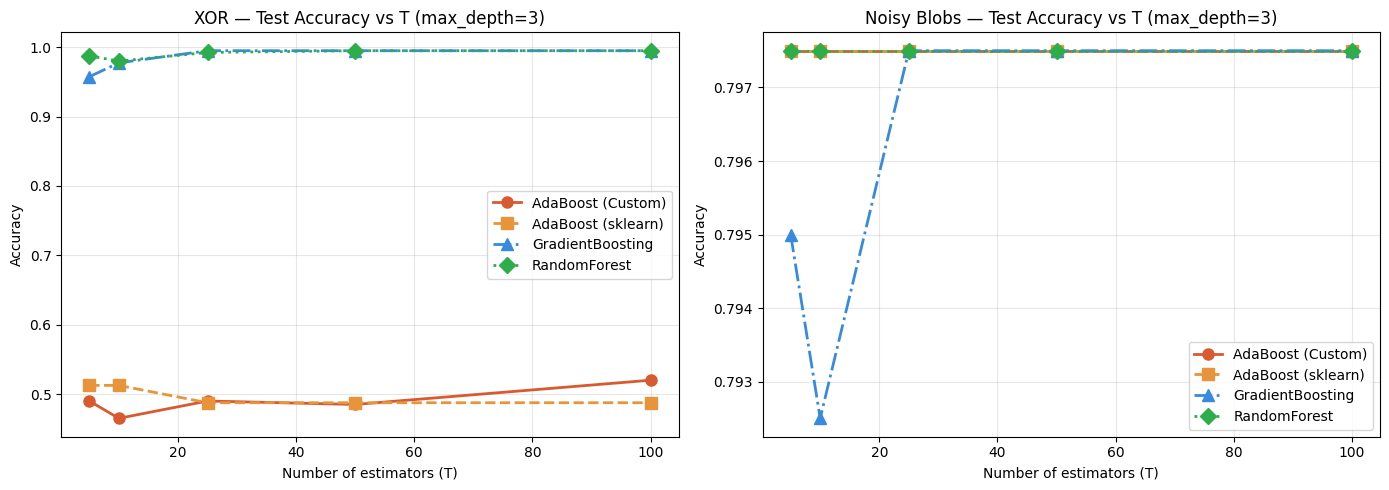

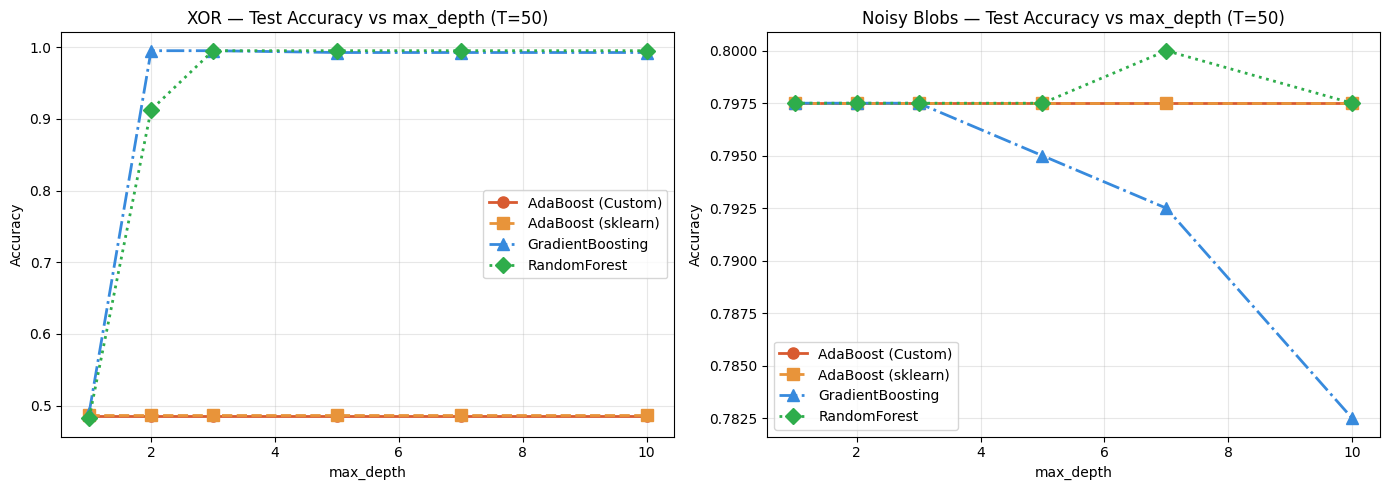

In [65]:
# ============================================================
# Plot Experiment 1: Test Accuracy vs T (fixed max_depth=3)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = {'AdaBoost (Custom)': '#D85A30', 'AdaBoost (sklearn)': '#E8943A',
          'GradientBoosting': '#378ADD', 'RandomForest': '#2EAD4B'}
markers = {'AdaBoost (Custom)': 'o', 'AdaBoost (sklearn)': 's',
           'GradientBoosting': '^', 'RandomForest': 'D'}
linestyles = {'AdaBoost (Custom)': '-', 'AdaBoost (sklearn)': '--',
              'GradientBoosting': '-.', 'RandomForest': ':'}

for col, ds_name in enumerate(datasets.keys()):
    ax = axes[col]
    for model_name in results_T[ds_name]:
        ax.plot(T_values, results_T[ds_name][model_name]['acc_test'],
                label=model_name, color=colors[model_name],
                marker=markers[model_name], linestyle=linestyles[model_name],
                linewidth=2, markersize=8)
    ax.set_title(f'{ds_name} — Test Accuracy vs T (max_depth=3)')
    ax.set_xlabel('Number of estimators (T)')
    ax.set_ylabel('Accuracy')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================
# Plot Experiment 2: Test Accuracy vs max_depth (fixed T=50)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for col, ds_name in enumerate(datasets.keys()):
    ax = axes[col]
    for model_name in results_depth[ds_name]:
        ax.plot(depth_values, results_depth[ds_name][model_name]['acc_test'],
                label=model_name, color=colors[model_name],
                marker=markers[model_name], linestyle=linestyles[model_name],
                linewidth=2, markersize=8)
    ax.set_title(f'{ds_name} — Test Accuracy vs max_depth (T=50)')
    ax.set_xlabel('max_depth')
    ax.set_ylabel('Accuracy')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Results Analysis

### XOR Dataset

**Experiment 1 (vary T, fixed max_depth=3):**
- GradientBoosting and RandomForest both reach near-perfect accuracy (~99-100%) quickly, since `max_depth=3` allows each tree to split on both features and capture the XOR pattern.
- Both AdaBoost versions are stuck at ~48-52% — essentially random guessing. This reveals a fundamental limitation: depth-1 stumps make a single axis-aligned cut, but on XOR each half of the plane contains equal amounts of both classes. No single stump can achieve better than chance, and boosting many useless stumps together still produces a useless ensemble.

**Experiment 2 (vary max_depth, fixed T=50):**
- GradientBoosting jumps to ~100% at `max_depth=2` — this is the minimum depth needed to split on both $x_1$ and $x_2$ within a single tree, which is exactly what XOR requires.
- RandomForest reaches ~100% at `max_depth=3`, slightly later because individual trees are trained on bootstrap samples (random subsets), so they need slightly more capacity.
- AdaBoost (both versions) stays flat at ~49% regardless of the `max_depth` parameter, confirming that it always uses depth-1 stumps by design.

**Conclusion:** The XOR dataset demonstrates that AdaBoost with stumps has a hard limitation on problems where no single axis-aligned split is informative. The weak learner must be at least minimally useful (error < 0.5) for boosting to work — on XOR with stumps, this condition is barely met or not met at all.

### Noisy Blobs Dataset

**Experiment 1 (vary T, fixed max_depth=3):**
- All models converge to approximately 79.7-79.8% accuracy, which aligns with the theoretical ceiling of $1 - \text{noise\_rate} = 0.80$. Since the two blobs are well-separated, even a small number of estimators (T=5) is sufficient to find the optimal boundary. Adding more estimators provides no benefit because the remaining errors are due to mislabeled points, not model capacity.

**Experiment 2 (vary max_depth, fixed T=50):**
- **GradientBoosting degrades significantly at higher depths** — dropping from ~79.7% at depth 1 to ~78.2% at depth 10. This is overfitting: deeper trees have enough capacity to memorize the mislabeled training points, which hurts generalization.
- **RandomForest remains stable** across all depths (~79.7-80%). Bagging naturally resists overfitting because averaging many independent trees smooths out the effect of individual mislabeled points.
- **AdaBoost stays flat** at ~79.7% since it ignores the `max_depth` parameter (always uses stumps).

**Conclusion:** The noisy dataset demonstrates that deeper trees are not always better — on noisy data, increased model capacity leads to overfitting. GradientBoosting is particularly vulnerable because it sequentially fits residuals, and mislabeled points create persistent large residuals that deeper trees try to memorize. RandomForest's parallel, independent training makes it naturally robust to label noise.

### Key Takeaway
The `max_depth` hyperparameter creates a fundamental tradeoff:
- On **clean, complex data** (XOR): deeper trees are essential — without sufficient depth, the base learners cannot capture the true pattern.
- On **noisy data** (blobs with flipped labels): deeper trees are harmful — they overfit to mislabeled points.

AdaBoost's fixed depth-1 design makes it immune to the depth-overfitting problem but also unable to solve problems where stumps are uninformative. This highlights why hyperparameter tuning (especially `max_depth`) is critical in practice, and why the choice of dataset properties directly impacts which algorithm performs best.

# Use of generative AI
Please use the cell below to describe your use of generative AI in this assignment. 